<a href="https://colab.research.google.com/github/ceciliafujita/FIAP_1IAST/blob/main/IAST1_TechChallenge_Fase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



### Notas:
- Github
- Arquivo README
- Comentários explicando o código - ok



## 1. IMPORTAR E CONHECER A BASE

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.stats import norm

nps_df = pd.read_csv("/content/desafio_nps_fase_1.csv")

In [ ]:
nps_df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
nps_df.tail()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7
2499,2500,35,Nordeste,109,52500,420.94,1,16.51,4,11,1,34.16,3,1,0,10.0,1,2,7.6


Possui 2.500 linhas e 19 colunas:

In [ ]:
#Visão geral da tabela
nps_df.shape

(2500, 19)

In [ ]:
#Detalhes da tabela, verificação de nulos e tipos de variável
nps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [ ]:
#customer_region é o único atributo não numérico, verificando se está padronizada
nps_df["customer_region"].unique()

array(['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste'],
      dtype=object)

## Análise
Não há valores nulos na tabela analisada, os tipos de dado estão adequados e a formatação dos nomes das variáveis está padronizada

Há somente uma variável qualitativa: *customer_region*

As restantes são quantitativas discretas (valor inteiro) ou contínuas (val *float*), conforme acima.

## 2. LIMPEZA E TRANSFORMAÇÃO DA BASE

### Valores Nulos
A base não possui valores nulos.

### Tratamento Estatístico
Vamos investigar a presença de outliers ou se algum dado extremo foi armazenado nas variáveis usando o intervalo interquartil.
+ IRQ = Q3 - Q1
+ Um dado é outlier se for menor que Q1 - 1,5 * IQR ou maior que Q3 + 1,5 * IQR

### Substituição - Winsorization - para NPS
Em vez de excluir os dado, substituir os outliers pelos valores limites aceitáveis (ex: percentis 5 e 95). Isso diminui o ruído.

### Regra de Contexto para NPS
No NPS, respostas 0 (detrator) ou 10 (Promotor) de forma discrepante podem ser consideradas outliers de contexto, ou seja, um ruído. No entanto, deve-se manter quando acompanhada de feedback detalhado.

In [ ]:
## colunas com variáveis quantitativas
col_qtv = nps_df.select_dtypes(include=np.number).columns

Q1 = nps_df[col_qtv].quantile(0.25)
Q3 = nps_df[col_qtv].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outlier_mask = ((nps_df[col_qtv] < limite_inf) | (nps_df[col_qtv] > limite_sup)) ## máscara.


outliers_df = nps_df[outlier_mask]
outliers_df

print(f"", Q1 ,"\n\n", Q3,"\n\n",  IQR,)
print(f"",limite_inf ,"\n\n", limite_sup ,"\n\n", outlier_mask,"\n\n",outliers_df)

## ------
## Só nps_score inteiro

### CRIAÇÃO DE UMA COLUNA DE NPS SCORE INTEIRO
nps_df.nps_int_score = nps_df.nps_score.round(0).astype(int)

Q1_nps = nps_df.nps_int_score.quantile(0.05)
print (Q1_nps)
Q3_nps = nps_df.nps_int_score.quantile(0.95)
print (Q3_nps)
IQR_nps = Q3_nps - Q1_nps

limite_nps_inf = Q1_nps - 1.5 * IQR_nps
limite_nps_sup = Q3_nps + 1.5 * IQR_nps

outlier_nps_mask = (([nps_df.nps_int_score] < limite_nps_inf) | ([nps_df.nps_int_score] > limite_nps_sup)) ## máscara.

outliers_nps_df = [outlier_nps_mask]
outliers_nps_df
print(f"\n\n", Q1_nps ,"\n\n", Q3_nps,"\n\n",  IQR_nps,"\n\n")
print(f"",limite_nps_inf ,"\n\n", limite_nps_sup ,"\n\n", outlier_nps_mask,"\n\n",outliers_nps_df,"\n\n")



 customer_id                    625.7500
customer_age                    31.0000
customer_tenure_months          31.0000
order_id                     50625.7500
order_value                    220.2450
items_quantity                   2.0000
discount_value                   8.8850
payment_installments             3.0000
delivery_time_days               5.0000
delivery_delay_days              1.0000
freight_value                   29.9275
delivery_attempts                1.0000
customer_service_contacts        1.0000
resolution_time_days             2.0000
nps_score                        2.6000
repeat_purchase_30d              0.0000
complaints_count                 3.0000
csat_internal_score              0.7000
nps_int                          2.6000
Name: 0.25, dtype: float64 

 customer_id                   1875.2500
customer_age                    56.0000
customer_tenure_months          91.0000
order_id                     51875.2500
order_value                    577.2900
items_qua

/tmp/ipykernel_33469/2045979910.py:24: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  nps_df.nps_int_score = nps_df.nps_score.round(0).astype(int)


/tmp/ipykernel_33469/4189066261.py:2: UserWarning:

Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access



Percentual de notas 0 sem e com arredondamento: 6.32%, 8.52%
Percentual de notas 10 sem e com arredondamento: 1.68%, 2.64%
 nps_score
0.0     6.32
0.1     0.32
0.2     0.56
0.3     0.40
0.4     0.56
        ... 
9.6     0.32
9.7     0.12
9.8     0.16
9.9     0.12
10.0    1.68
Name: proportion, Length: 101, dtype: float64 /n/n nps_score
0      8.52
1      5.32
2     11.08
3     12.00
4     15.68
5     13.12
6     14.32
7      8.24
8      5.80
9      3.28
10     2.64
Name: proportion, dtype: float64


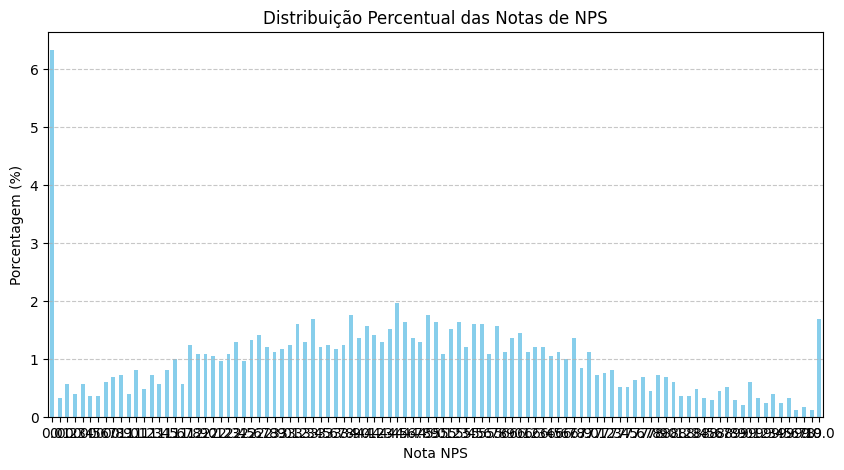

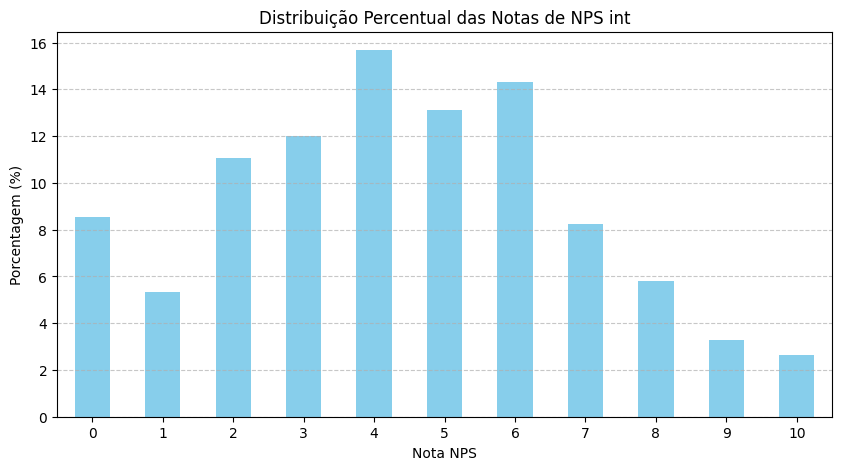

Porcentagem de Promotores int: 6%
Porcentagem de Neutros int: 14%
Porcentagem de Detratores int: 80%


In [ ]:
# Qual o % de notas 0 no nps_score?
nps_df.nps_int_score = nps_df.nps_score.round(0).astype(int)

nps_perc_0 = (nps_df.nps_score == 0).mean() * 100
nps_int_perc_0 = (nps_df.nps_int_score == 0).mean() * 100

print(f"Percentual de notas 0 sem e com arredondamento: {nps_perc_0}%, {nps_int_perc_0}%")

# Qual o % de notas 10 no nps_score?
nps_perc_10 = (nps_df.nps_score == 10).mean() * 100
nps_int_perc_10 = (nps_df.nps_int_score == 10).mean() * 100

print(f"Percentual de notas 10 sem e com arredondamento: {nps_perc_10}%, {nps_int_perc_10}%")


distribuicao_nps = nps_df.nps_score.value_counts(normalize=True).sort_index()  * 100
distribuicao_nps_int = nps_df.nps_int_score.value_counts(normalize=True).sort_index()  * 100

print(f" {distribuicao_nps} /n/n {distribuicao_nps_int}")

plt.figure(figsize=(10, 5))
distribuicao_nps.plot(kind='bar', color='skyblue')

plt.title('Distribuição Percentual das Notas de NPS')
plt.xlabel('Nota NPS')
plt.ylabel('Porcentagem (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


plt.figure(figsize=(10, 5))
distribuicao_nps_int.plot(kind='bar', color='skyblue')

plt.title('Distribuição Percentual das Notas de NPS int')
plt.xlabel('Nota NPS')
plt.ylabel('Porcentagem (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#---
promotores_int = nps_df.nps_int_score.isin([9, 10]).mean() * 100
print(f"Porcentagem de Promotores int: {promotores_int:.0f}%")

neutros_int = nps_df.nps_int_score.isin([7, 8]).mean() * 100
print(f"Porcentagem de Neutros int: {neutros_int :.0f}%")

detratores_int = nps_df.nps_int_score.isin([0, 1, 2, 3, 4, 5, 6]).mean() * 100
print(f"Porcentagem de Detratores int: {detratores_int:.0f}%")



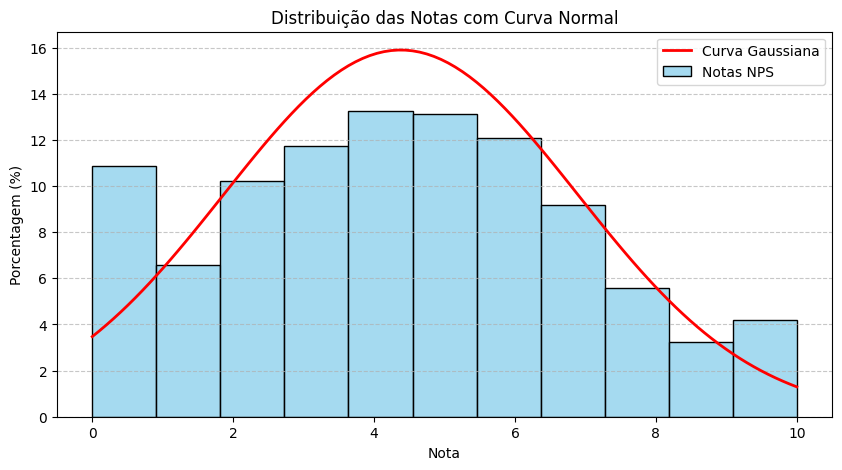

In [ ]:


# 1. Configura o tamanho e os dados
plt.figure(figsize=(10, 5))
data = nps_df['nps_score'] # Usei a coluna original de nps

# 2. Plota o histograma em densidade (necessário para a curva encaixar)
# stat='percent' faz com que o eixo Y seja a porcentagem
sns.histplot(data, bins=11, kde=False, stat="percent", color='skyblue', label='Notas NPS')

# 3. Calcula e plota a Gaussiana
# Criamos um eixo X suave entre 0 e 10
x = np.linspace(0, 10, 100)
# Calculamos a média e o desvio padrão dos dados reais
mu, std = data.mean(), data.std()
# A função norm.pdf gera a curva. Multiplicamos por 100 (ou o fator de escala)
# para que ela suba até o nível das porcentagens do gráfico
p = norm.pdf(x, mu, std) * 100

plt.plot(x, p, 'r', linewidth=2, label='Curva Gaussiana')

# 4. Formatação
plt.title('Distribuição das Notas com Curva Normal')
plt.xlabel('Nota')
plt.ylabel('Porcentagem (%)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


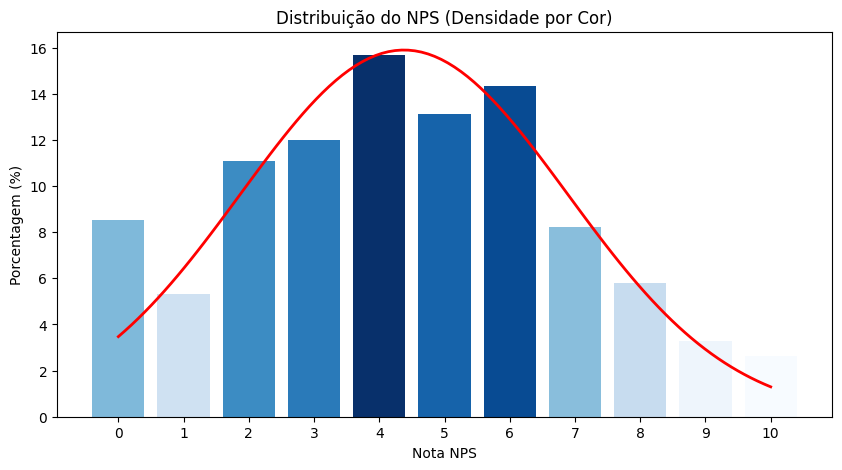

In [ ]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar os dados
dist = nps_df['nps_score'].round(0).astype(int).value_counts(normalize=True).sort_index() * 100

# 2. Configurar o Colormap (tons de azul)
# 'Blues' é o mapa de cores que vai do claro ao escuro
cmap = plt.get_cmap('Blues')
# Normalizamos os valores entre 0 e 1 para o colormap entender
rescale = lambda y: (y - y.min()) / (y.max() - y.min())

plt.figure(figsize=(10, 5))

# 3. Plotar as barras com as cores mapeadas
# color=cmap(rescale(dist.values)) aplica a cor proporcional à altura
plt.bar(dist.index.astype(str), dist.values, color=cmap(rescale(dist.values)))

# 4. Calcula e plota a Gaussiana
# Criamos um eixo X suave entre 0 e 10
x = np.linspace(0, 10, 100)
# Calculamos a média e o desvio padrão dos dados reais
mu, std = data.mean(), data.std()
# A função norm.pdf gera a curva. Multiplicamos por 100 (ou o fator de escala)
# para que ela suba até o nível das porcentagens do gráfico
p = norm.pdf(x, mu, std) * 100

plt.plot(x, p, 'r', linewidth=2, label='Curva Gaussiana')

# 5. Estilização
plt.title('Distribuição do NPS (Densidade por Cor)')
plt.xlabel('Nota NPS')
plt.ylabel('Porcentagem (%)')
plt.grid(axis='y', linestyle='',  alpha=0.3)

plt.show()


Quais colunas possuem outliers:

In [ ]:
outliers_df.count()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,84
items_quantity,0
discount_value,125
payment_installments,0
delivery_time_days,0


Mantendo somente as colunas que possuem outliers e em que os outliers poderiam impactar a análise:

In [ ]:
outliers_df = outliers_df.loc[: ,['order_value', 'discount_value', 'delivery_delay_days', 'freight_value', 'customer_service_contacts', 'complaints_count']]
outliers_df

,order_value,discount_value,delivery_delay_days,freight_value,customer_service_contacts,complaints_count
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,4.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2495,NaN,NaN,NaN,NaN,NaN,NaN
2496,NaN,NaN,NaN,NaN,NaN,NaN
2497,NaN,NaN,NaN,NaN,NaN,NaN
2498,NaN,NaN,NaN,NaN,NaN,NaN


Analisando dentre esses outliers qual é o de menor e maior valor:

In [ ]:
col = outliers_df.columns

outliers_df[col].max()

,0
order_value,1983.81
discount_value,230.33
delivery_delay_days,8.00
freight_value,76.13
customer_service_contacts,7.00
complaints_count,11.00


In [ ]:
outliers_df[col].min()

,0
order_value,1112.92
discount_value,89.05
delivery_delay_days,7.00
freight_value,2.62
customer_service_contacts,4.00
complaints_count,9.00


Com isso, chegamos a conclusão de que apesar da base possuir outliers, eles não parecem influenciar de forma negativa na análise. Pelo contrário, os outliers nesse caso podem nos ajudar a investigar do motivo do NPS estar insatisfatório.

# 3. Medidas Resumo Principais

## Medidas Resumo

In [ ]:
nps_df.describe().iloc[1:, 1:].style.format("{:.2f}") ## Retirando o count e arrendondando para deixar mais limpo



,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_int
mean,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94,4.38
std,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38,2.51
min,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,50625.75,220.25,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70,2.60
50%,43.00,62.00,51250.50,375.51,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80,4.40
75%,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80,6.10
max,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00,10.00


## Análise

Em médias nossos clientes tem um tempo de permanência na plataforma de 5 anos, com idade média de 43 anos.

O ticket médio é de R$434, com mais de 3 itens por compra, parcelados em até 11x.

Prazo de Entrega é de 2 a 14 dias, a média são 8 dias. Com um atraso médio de mais de 2 dias e duas tentativas de entrega.

A cada 3 clientes, 2 entram em contato com central de atendimento. A média de tempo de resolução é de 5.5 dias. Acumulando uma média de mais de 4 reclamações por cliente.  

O percentual de promotores é de 6%, neutros 14% e detratores somam 80% da nossa base. Com score médio de apenas 4.4 (nps).

Somente 9% dos cliente voltam a comprar em menos de 30 dias (repeat users).


# 4. Matriz de Correlação

Como há muitas variáveis no DF, faremos uma matriz de correlação para saber onde estão as maiores correlações e focar diretamente nessas variáveis. Assim poupamos tempo, código e a base fica mais limpa

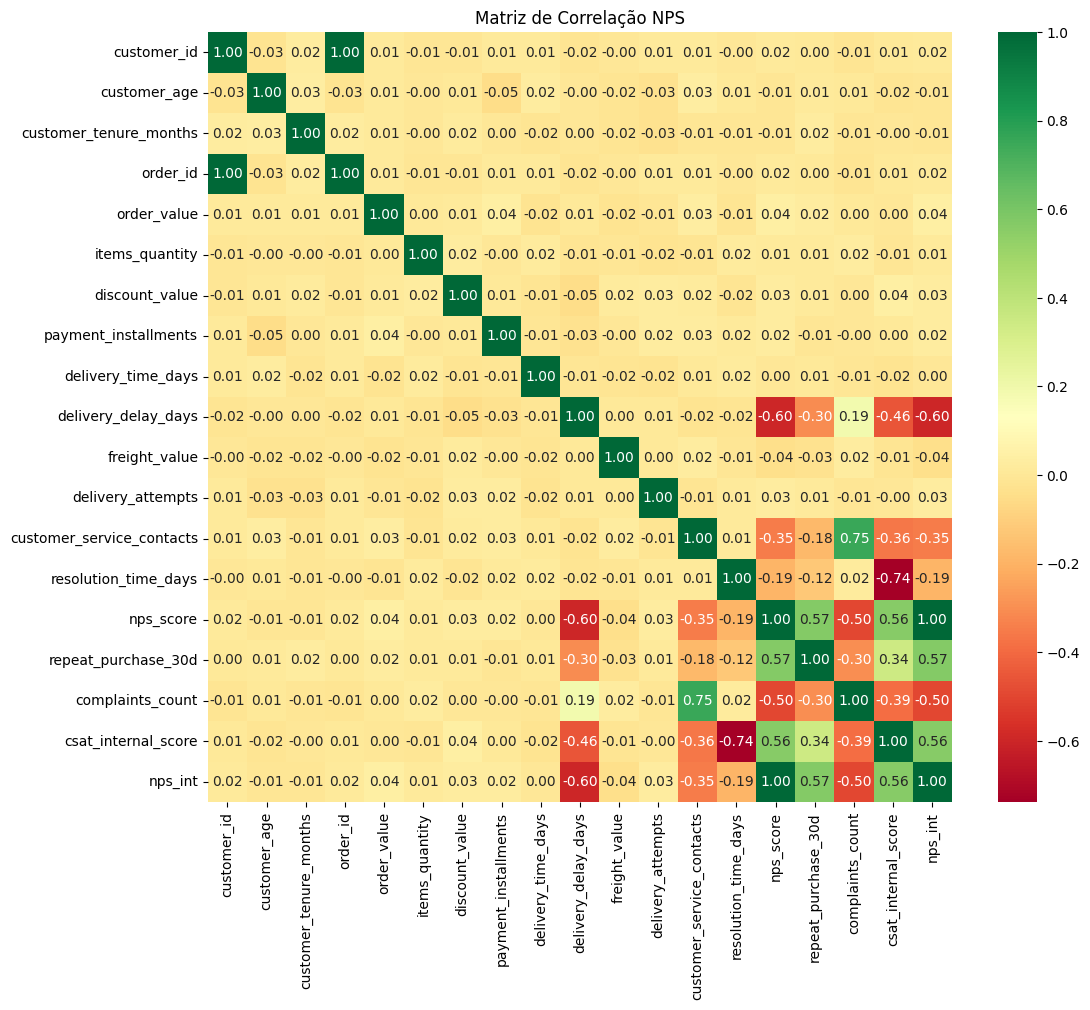

,0


In [ ]:
nps_df_num = nps_df.select_dtypes(include=['int64', 'float64'])

corr = nps_df_num.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='RdYlGn', annot=True, fmt=".2f")
plt.title("Matriz de Correlação NPS")
plt.show()


nps_df.isnull().sum()[nps_df.isnull().sum() > 0]

## Variáveis (numéricas) que possuem maior correlação negativa com o nps:
1. delivery_delay_days
2. customer_service_contacts
3. resolution_time_days
4. complaints_count

## Variáveis (numéricas) que possuem maior correlação positiva com o nps:
1. repeat_purchase_30d
2. csat_internal_score

# Iniciando a Análise

## Classificar os clientes entre detratores, neutros e promotores
Utilizaremos para isso o padrão de mercado, com seguinte range de score:
+ De 0 a 6 - Detrator
+ De 7 e 8 - Neutro
+ De 9 e 10 - Promotor


In [ ]:
### CRIAÇÃO DE UMA COLUNA DE NPS SCORE INTEIRO
nps_df.nps_int_score = nps_df.nps_score.round(0).astype(int)

condicoes = [
    (nps_df.nps_int_score< 7),
    (nps_df.nps_int_score >= 7) & (nps_df.nps_int_score < 9),
    (nps_df.nps_int_score >= 9)
    ]

classificacao = ['Detrator', 'Neutro', 'Promotor']

nps_df['classificacao_nps'] = np.select(condicoes, classificacao, default="Sem Nota")
nps_df

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_int,classificacao_nps
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,55.53,3,0,4,6.9,0,3,6.5,6.9,Neutro
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,28.23,3,0,10,2.4,0,3,0.0,2.4,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,40.99,1,4,5,4.8,0,7,1.5,4.8,Detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,35.24,3,1,11,5.9,0,4,0.3,5.9,Detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,39.32,1,1,0,6.1,0,3,7.9,6.1,Detrator
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,...,28.96,2,1,2,3.7,0,3,4.3,3.7,Detrator
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,...,27.42,2,2,7,3.7,0,4,2.5,3.7,Detrator
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,...,38.94,1,1,1,7.4,0,3,6.2,7.4,Neutro
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,...,29.10,3,3,0,2.3,0,5,1.7,2.3,Detrator


In [ ]:


#---
promotores_int = nps_df.nps_int_score.isin([9, 10]).mean() * 100
print(f"Porcentagem de Promotores int: {promotores_int:.0f}%")

neutros_int = nps_df.nps_int_score.isin([7, 8]).mean() * 100
print(f"Porcentagem de Neutros int: {neutros_int :.0f}%")

detratores_int = nps_df.nps_int_score.isin([0, 1, 2, 3, 4, 5, 6]).mean() * 100
print(f"Porcentagem de Detratores int: {detratores_int:.0f}%")

nps_df.value_counts('classificacao_nps')

Porcentagem de Promotores int: 6%
Porcentagem de Neutros int: 14%
Porcentagem de Detratores int: 80%


,count
classificacao_nps,
Detrator,2001
Neutro,351
Promotor,148


Identificamos uma quantidade preocupante de clientes Detratores, 80%. Isso nos informa que os clientes não estão satisfeitos com a empresa e que no longo prazo é possível que haja um grande impacto negativo nas vendas.

## Identificando as possíveis causas

### Região

In [ ]:
pd.crosstab(nps_df['customer_region'], nps_df['classificacao_nps'], normalize='index').round(2)* 100

classificacao_nps,Detrator,Neutro,Promotor
customer_region,,,
Centro-Oeste,80.0,13.0,7.0
Nordeste,79.0,15.0,6.0
Norte,81.0,14.0,5.0
Sudeste,80.0,14.0,6.0
Sul,80.0,14.0,6.0


Existem diferenças entre a quantidade de detratores por região. Porém essa diferença é pequena e se mantém consistente entre regiões.
Insight: a região não parece influenciar se o cliente terá uma má ou boa experiência.

### Atraso na Entrega

In [ ]:
pd.crosstab(nps_df['delivery_delay_days'], nps_df['classificacao_nps'], normalize='index').round(3) * 100

classificacao_nps,Detrator,Neutro,Promotor
delivery_delay_days,,,
0,45.1,31.0,23.8
1,66.8,23.4,9.8
2,83.1,14.1,2.8
3,94.1,5.1,0.8
4,98.9,1.1,0.0
5,100.0,0.0,0.0
6,100.0,0.0,0.0
7,100.0,0.0,0.0
8,100.0,0.0,0.0


O atraso na entrega apresenta um alto impacto na satisfação do cliente. Foi observado que a partir de 2 dias de atraso, a probabilidade de um cliente se tornar detrator ultrapassa 80%.
Há outros fatores a serem analisados, pois mesmo sem atraso na entrega, ainda temos um percentual elevado de detratores (45%).
De qualquer forma, o atraso na entrega é um fator crítico.

### Tempo de entrega

In [ ]:
pd.crosstab(nps_df['delivery_time_days'], nps_df['classificacao_nps'], normalize='index').round(3) * 100

classificacao_nps,Detrator,Neutro,Promotor
delivery_time_days,,,
2,83.3,10.8,5.9
3,77.6,15.8,6.6
4,81.9,12.7,5.4
5,82.0,12.6,5.5
6,78.6,18.1,3.3
7,76.5,15.3,8.2
8,78.2,13.4,8.4
9,83.2,12.0,4.7
10,77.5,16.3,6.2


Não parece haver correlação entre o tempo de entrega e a quantidade de detratores.

Com um tempo de entrega de 2 dias, há um percentual de 83% de detratores, enquanto um tempo de entrega de 13 dias há um percentual de 76% de detratores.

O tempo de entrega não é um fator crítico.

In [ ]:
print(f'Média Tempo de Entrega: {nps_df['delivery_time_days'].mean()}')

Média Tempo de Entrega: 8.022


# Recomendações
Percebemos que os clientes não se incomodam com tempos de entrega elevados, mesmo acima da média. Os clientes se importam com o compromisso: se houver atraso, há insatisfação.

Recomendação 1: Conceder maiores prazos para a entrega a fim de conseguir cumprí-los, visto que o cliente não parece considerar o prazo na avaliação, e sim o atraso.

No entanto, se aumentarmos a previsão de entrega, os clientes podem acabar desistindo da compra. Essa abordagem precisa ser discutida com os profissionais da área.

Sugerimos realizar um teste AB para um segmento da base e verificar como se comporta o cliente quando alteramos o prazo de entrega.


Recomendação 2: Diminuir o tempo de entrega para cumprimento dos prazos estabelecidos.

Se faz necessária a revisão de todo o processo logístico para tentar encontrar possíveis gargalos que impeçam que a entrega seja feita no prazo estimado.

Outras soluções possíveis pode ser o aumento da frota e/ou funcionário, novos polos de distribuição, alteração do método de entrega, ou terceirização da entrega. Contudo, isso pode aumentar os custos e tornar o negócio menos lucrativo ou insustentável.

A viabilidade deve ser discutida com o setor de logística e afins.


Ao realizar o teste AB de aumento de prazo, será possível verificar se outras métricas sofrem impacto positivo ou negativo.Métricas como desistência de compra/abandono de carrinho, impacto no nps, quantidade de contato com o atendimento, ticket médio, entre outras.

#### Há alguma região em que as entregas atrasem mais?

In [ ]:
fig = px.box(nps_df, x='customer_region', y='delivery_delay_days',color='customer_region', points='all')
fig.show()

In [ ]:
nps_df.groupby('customer_region')['delivery_delay_days'].mean().sort_values(ascending=False)

,delivery_delay_days
customer_region,
Centro-Oeste,2.222222
Sudeste,2.217308
Nordeste,2.185567
Sul,2.168906
Norte,2.144269


In [ ]:
nps_df.groupby('customer_region')['delivery_delay_days'].mean().sort_values(ascending=False).apply(np.ceil).astype(int) #considerando o arredondamento de dias, porque podemos dizer que se o produto demorou 1,3 dias para chegar, na visão do cliente são 2 dias de atraso.

,delivery_delay_days
customer_region,
Centro-Oeste,3
Sudeste,3
Nordeste,3
Sul,3
Norte,3


## Análise

Com o gráfico box-plot, vemos que apesar de o atraso se mostrar consistente entre as regiões, é possível notar a presença de alguns casos extremos no  norte e sudeste (atraso de até 8 dias). Embora, todas as regiões já sofreram com atrasos acima de 7 dias.  

Apesar disso, considerando que já foi identificado que atrasos a partir de 2 dias elevam a probabilidade de um cliente se tornar detrator em 83%, atrasos ainda maiores (entre 5 e 8 dias) não aumentam proporcionalmente essa probabilidade (que já chega a 100% nesses casos).  

O motivo de atrasos tão altos merece uma investigação.

Recomendação: Teste AB de troca de fornecedor. Sugestão , testar novas parceirias para logistica - estima baixo impacto financeiro e possibilidade de ganho.
Vale à pena cuidar melhor da entrega por ela ter tanto impacto no negócio.

## Quantidade de Contatos com o Atendimento ao Cliente

In [ ]:
pd.crosstab(nps_df['complaints_count'], nps_df['classificacao_nps'], normalize='index').round(3) * 100

classificacao_nps,Detrator,Neutro,Promotor
complaints_count,,,
0,8.7,39.1,52.2
1,19.7,49.2,31.1
2,55.2,30.3,14.4
3,76.1,18.5,5.3
4,86.8,9.0,4.2
5,91.7,7.2,1.1
6,95.9,4.1,0.0
7,95.9,4.1,0.0
8,100.0,0.0,0.0


Há uma correlação muito forte entre a quantidade de reclamações e o cliente ser detrator. Mas, do que o cliente está reclamando?

Na análise entre as variáveis customer_service_contacts, resolution_time_days e outras da base, não foi encontrada correlação entre a quantidade de reclamações e o tempo de atraso, por exemplo.

Vamos verificar se alguma região possui mais reclamação que outras:

## Quantidade de Reclamações

In [ ]:
bins = [-1, 0, 2, 5, 20] ## intervalos de qtd de reclamações
faixas = ['0', '1-2', '3-5', '6+']

nps_df['faixa_reclamacoes'] = pd.cut(nps_df['complaints_count'],bins=bins, labels=faixas) ## criar faixa de quantidade a partir da coluna original de reclamações

tabela = pd.crosstab(nps_df['customer_region'], nps_df['faixa_reclamacoes'], normalize='index').round(3) * 100

tabela

faixa_reclamacoes,0,1-2,3-5,6+
customer_region,,,,
Centro-Oeste,0.6,15.8,63.9,19.7
Nordeste,1.0,17.1,60.0,21.9
Norte,0.8,16.0,62.6,20.6
Sudeste,0.4,13.3,64.4,21.9
Sul,1.7,17.7,59.3,21.3


## Análise

Não parece haver correlação entre a região e a quantidade de reclamações.

#Conclusão e Recomendação

Gostaríamos de evitar que o cliente reclame ou que seja um detrator, mas isso não é possível sem antes sabermos o que está causando sua insatisfação além do atraso na entrega.
Podemos notar que, com uma reclamação a possibilidade do cliente se tornar detrator sobe 10%, com 2 reclamações sobe mais 35%.

Recomendação: classificar as reclamações entre tipos e solicitar, enquanto o cliente abre a demanda, em qual categoria a reclamação dele se encaixa. Assim podemos identificar onde está o problema.

Cada vez fica mais claro a importância de estabelecer avaliações intrajornada, pois com elas seria possível identificar outros pontos críticos e gargalos do cliente dentro de todo o processo de compra. Afinal, 45% deles, mesmo sem atraso na entrega de seus produtos, estão como detratores.
Um dos cuidado que podemos tomar para as avaliações intraprocesso não serem mais um ponto de atrito nessa jornada, seria estabelecer medições por segmentos da base (Testes ABs).

# Atrasos Vs a probabilidade de virar um Detrator
## Modelo de Regressão Logistica

Queremos ver os Atrasos Vs a probabilidade de virar um Detrator.


### Ponto Crítico

Achar o ponto crítico no atraso onde o cliente passa ser detrator.

In [25]:
import statsmodels.api as sm


X = sm.add_constant(nps_df['delivery_delay_days'])
y = (nps_df['nps_score'] <= 6).astype(int)

# Treinar o modelo
modelo = sm.Logit(y, X).fit()

# Calcular o ponto de virada (Onde a chance cruza os 50%)
# Fórmula: -intercepto / coeficiente_do_atraso
intercepto, slope = modelo.params
dia_critico = -intercepto / slope

print(f"O dia crítico é: {dia_critico:.1f} dias")

Optimization terminated successfully.
         Current function value: 0.473788
         Iterations 6
O dia crítico é: 0.6 dias


### Gráfico de Regressão Logistica

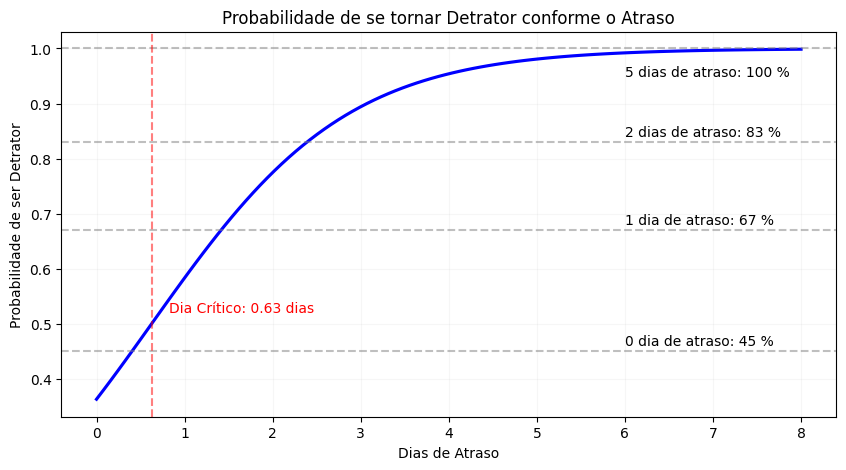

In [77]:

nps_df['is_detrator'] = (nps_df['nps_score'] <= 6).astype(int) #coluna booleana: True se nota <= 6 (Detrator)

plt.figure(figsize=(10, 5))

# Regplot com logistic=True parar calcular a probabilidade automaticamente
sns.regplot(x='delivery_delay_days', y='is_detrator', data=nps_df, logistic=True, ci=None
            , scatter_kws={'alpha':0.2}, line_kws={'color':'blue'}, scatter=False
            )
# linhas guia % de chance de detrator por atraso, como visto acima em https://colab.research.google.com/drive/1kln_aBzqosl7j4BmDbbUrJOKUQpUIiWq#scrollTo=NChJVnx8r3O8
plt.axhline(0.45, color='gray', linestyle='--', alpha=0.5) # linha no 0,45 - detrator em 0 dia atraso
plt.text(6, 0.46, f'0 dia de atraso: {45} %', color='black')

plt.axhline(0.67, color='gray', linestyle='--', alpha=0.5) # linha no 0,67 - detrator em 1 dia atraso
plt.text(6, 0.68, f'1 dia de atraso: {67} %', color='black')

plt.axhline(0.83, color='gray', linestyle='--', alpha=0.5) # linha no 0,83 - detrator em 2 dias atraso
plt.text(6, 0.84, f'2 dias de atraso: {83} %', color='black')

plt.axhline(1, color='gray', linestyle='--', alpha=0.5) # linha no 1 - detrator em 5 dias atraso
plt.text(6, 0.95, f'5 dias de atraso: {100} %', color='black')


plt.axvline(dia_critico, color='red', linestyle='--', alpha=0.5) # linha no dia crítico

plt.text(dia_critico + 0.2, 0.52, f'Dia Crítico: {dia_critico:.2f} dias',
         color='red')

plt.title('Probabilidade de se tornar Detrator conforme o Atraso')
plt.xlabel('Dias de Atraso')
plt.ylabel('Probabilidade de ser Detrator')
plt.grid(True,linestyle='-', alpha=0.1)
plt.show()

In [24]:
nps_df.groupby(pd.cut(nps_df['delivery_delay_days'], bins=5))['is_detrator'].mean().round(2)

/tmp/ipykernel_746/2738719368.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nps_df.groupby(pd.cut(nps_df['delivery_delay_days'], bins=5))['is_detrator'].mean().round(2)


,is_detrator
delivery_delay_days,
"(-0.008, 1.6]",0.52
"(1.6, 3.2]",0.82
"(3.2, 4.8]",0.96
"(4.8, 6.4]",0.99
"(6.4, 8.0]",1.00


# Análise

Usamos a regressão logística para mostrar a relação de Atraso Versus a probabilidade de ser um Detrator que já verificamos anteriormente.
À partir de um atraso de 0,6 dia, o cliente já tem grande chance de se tornar um detrator.

Suspeitamos que outros problemas, que não somente o atraso, esteja impactando a experiencia do cliente. Por isso a grande necessidade de medições intrajornada.



